In [2]:
import kagglehub
import os

path = kagglehub.dataset_download("mateuszbuda/lgg-mri-segmentation")
print("Path to dataset files:", path)

100%|██████████| 714M/714M [00:16<00:00, 44.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/mateuszbuda/lgg-mri-segmentation/versions/2


In [3]:
!pip install -q segmentation_models_pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.9 MB/s eta 0:00:00


In [4]:
# List the contents of the dataset folder
dataset_root = os.path.join(path, "lgg-mri-segmentation", "kaggle_3m")
print("Dataset contents:")
print(os.listdir(dataset_root)[:10])  # Show first 10 patient folders

Dataset contents:
['TCGA_DU_6408_19860521', 'README.md', 'TCGA_DU_7299_19910417', 'TCGA_HT_7473_19970826', 'TCGA_HT_7686_19950629', 'TCGA_CS_4943_20000902', 'TCGA_HT_7616_19940813', 'TCGA_CS_4942_19970222', 'TCGA_DU_7008_19830723', 'TCGA_HT_7874_19950902']


In [5]:
image_paths = []
mask_paths = []
# Loop through all patient folders
for patient_folder in os.listdir(dataset_root):
  patient_path = os.path.join(dataset_root, patient_folder)
  if os.path.isdir(patient_path):
    for filename in os.listdir(patient_path):
      # TODO: Check if the file is a mask (contains "_mask")
      # If it's a mask, add to mask_paths
      # Otherwise, if it's a .tif file, add to image_paths
      # YOUR CODE HERE
      if "_mask" in filename:
        mask_paths.append(os.path.join(patient_path, filename))
      elif filename.endswith(".tif"):
        image_paths.append(os.path.join(patient_path, filename))
print(f"Total images: {len(image_paths)}")
print(f"Total masks: {len(mask_paths)}")

Total images: 3929
Total masks: 3929


In [6]:
# Select samples with tumors
import numpy as np
from PIL import Image
samples_with_tumor = []
for img_path, mask_path in zip(image_paths, mask_paths):
  mask = np.array(Image.open(mask_path))
  if np.sum(mask) > 0:  # Has tumor pixels
    samples_with_tumor.append((img_path, mask_path))
image_paths = [s[0] for s in samples_with_tumor]
mask_paths = [s[1] for s in samples_with_tumor]
print(f"Total samples: {len(samples_with_tumor)}")

Total samples: 1373


In [7]:
import torch
from torch.utils.data import Dataset
import torchvision.transforms as transforms
def remap_mask_binary(mask):
  mask_np = mask.numpy().squeeze()
  binary_mask = (mask_np != 0).astype(np.uint8)
  return torch.from_numpy(binary_mask).unsqueeze(0)

In [8]:
class BrainMRIDataset(Dataset):
  def __init__(self, image_paths, mask_paths, transform=None, target_transform=None):
     self.image_paths = image_paths
     self.mask_paths = mask_paths
     self.transform = transform
     self.target_transform = target_transform
  def __len__(self):
     return len(self.image_paths)
  def __getitem__(self, idx):

     image = Image.open(self.image_paths[idx]).convert("RGB")
     mask = Image.open(self.mask_paths[idx]).convert("L")
  # Apply transforms
     if self.transform:
       image = self.transform(image)
     if self.target_transform:
        mask = self.target_transform(mask)
        mask = remap_mask_binary(mask)  # Convert to binary mask
     return image, mask

In [23]:
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

image_transforms = transforms.Compose([

  transforms.ToTensor(),
  transforms.Resize((256, 256)),
  transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

mask_transforms = transforms.Compose([

  transforms.Resize((256, 256), interpolation=transforms.InterpolationMode.NEAREST),
  transforms.PILToTensor(),
])

In [27]:
train_images, test_images, train_masks, test_masks = train_test_split(
  image_paths, mask_paths, test_size=0.2, random_state=42
)
# Create Dataset objects
train_dataset = BrainMRIDataset(train_images, train_masks, transform=image_transforms, target_transform=mask_transforms)
test_dataset = BrainMRIDataset(test_images, test_masks, transform=image_transforms, target_transform=mask_transforms)
# Create DataLoaders
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Train samples: 1098
Test samples: 275


In [28]:
def denormalize(img):
  mean = np.array([0.485, 0.456, 0.406])
  std = np.array([0.229, 0.224, 0.225])
  img = img.permute(1, 2, 0).numpy()  # CHW -> HWC
  img = img * std + mean
  img = np.clip(img, 0, 1)
  return img

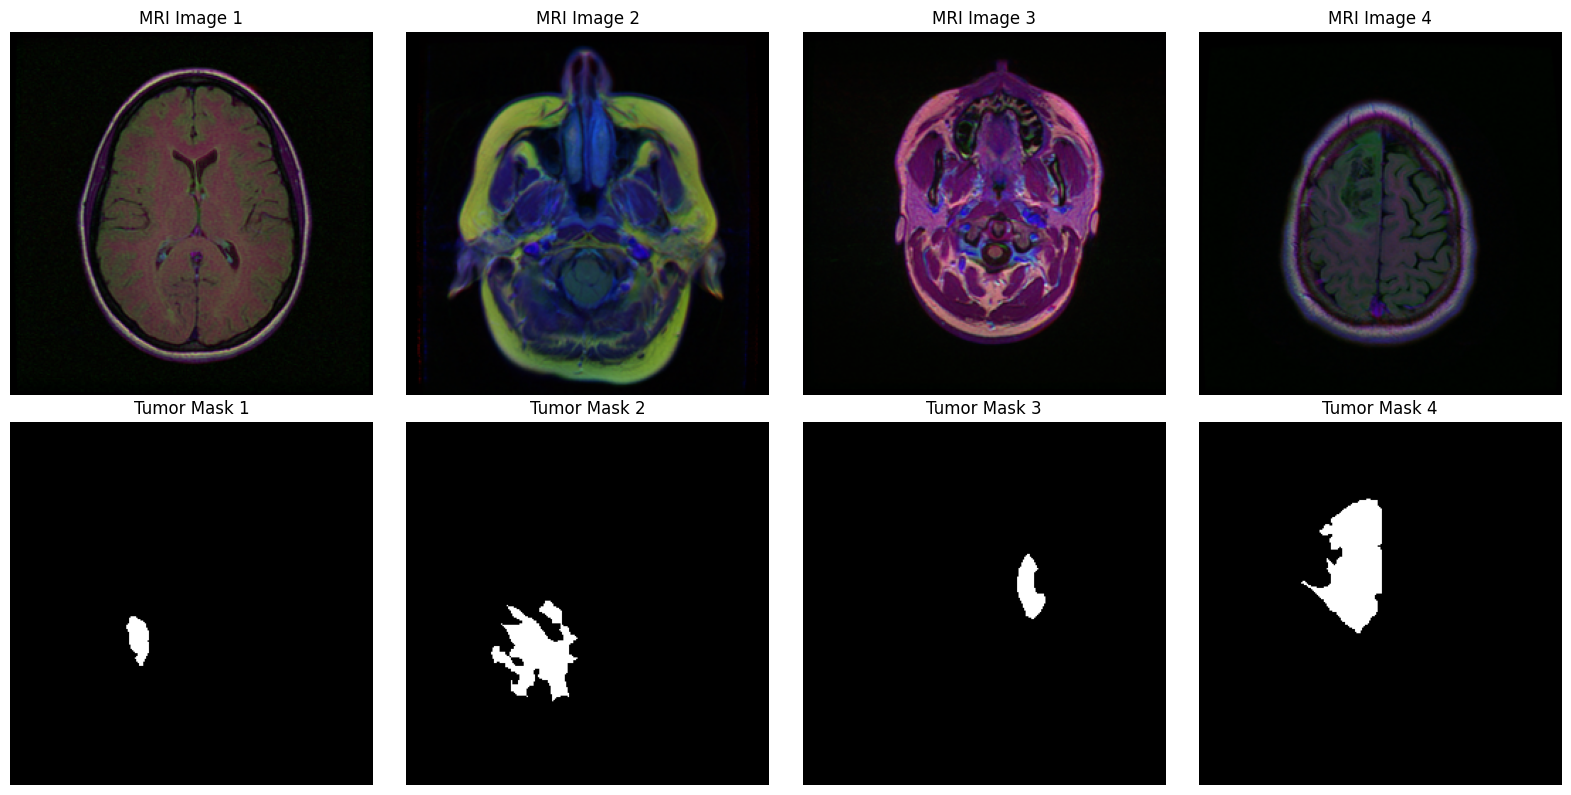

In [31]:
# Display 4 images with their masks side by side
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i in range(4):
    image, mask = train_dataset[i]
    # Display image (denormalize first)
    axes[0, i].imshow(denormalize(image))
    axes[0, i].set_title(f"MRI Image {i+1}")
    axes[0, i].axis("off")
    # Display mask
    axes[1, i].imshow(mask.squeeze(), cmap="gray")
    axes[1, i].set_title(f"Tumor Mask {i+1}")
    axes[1, i].axis("off")
plt.tight_layout()
plt.show()

In [13]:
import segmentation_models_pytorch as smp
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [14]:
model = smp.Unet(
  encoder_name="resnet34",
  encoder_weights="imagenet",
  in_channels=3,
  classes=1,
).to(device)
model = model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

In [15]:
import torch.optim as optim
from tqdm import tqdm
def train_one_epoch(model, dataloader, criterion, optimizer, device):
  model.train()
  total_loss = 0
  for images, masks in tqdm(dataloader):
    # Move data to device
    images, masks = images.to(device), masks.to(device).float()

    outputs = model(images)
    loss = criterion(outputs, masks)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    total_loss += loss.item()
  return total_loss / len(dataloader)

In [16]:
def validate(model, dataloader, criterion, device):
  model.eval()
  total_loss = 0
  with torch.no_grad():
   for images, masks in dataloader:
     images, masks = images.to(device), masks.to(device).float()

   outputs = model(images)
   loss = criterion(outputs, masks)
   total_loss += loss.item()
  return total_loss / len(dataloader)

In [17]:
from torch import nn

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4)
num_epochs = 10

In [ ]:
# Run training
train_losses = []
val_losses = []
for epoch in range(num_epochs):
  train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
  val_loss = validate(model, test_loader, criterion, device)
  train_losses.append(train_loss)
  val_losses.append(val_loss)
  print(f"Epoch {epoch+1}/{num_epochs}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}")

100%|██████████| 35/35 [21:51<00:00, 37.48s/it]


Epoch 1/10: Train Loss = 0.2617, Val Loss = 0.0280


100%|██████████| 35/35 [21:43<00:00, 37.26s/it]


Epoch 2/10: Train Loss = 0.2362, Val Loss = 0.0253


100%|██████████| 35/35 [21:34<00:00, 36.98s/it]


...

100%|██████████| 35/35 [21:20<00:00, 36.60s/it]


Epoch 8/10: Train Loss = 0.1327, Val Loss = 0.0170


100%|██████████| 35/35 [21:21<00:00, 36.62s/it]


Epoch 9/10: Train Loss = 0.1225, Val Loss = 0.0159


 80%|████████  | 28/35 [17:24<04:18, 36.86s/it]

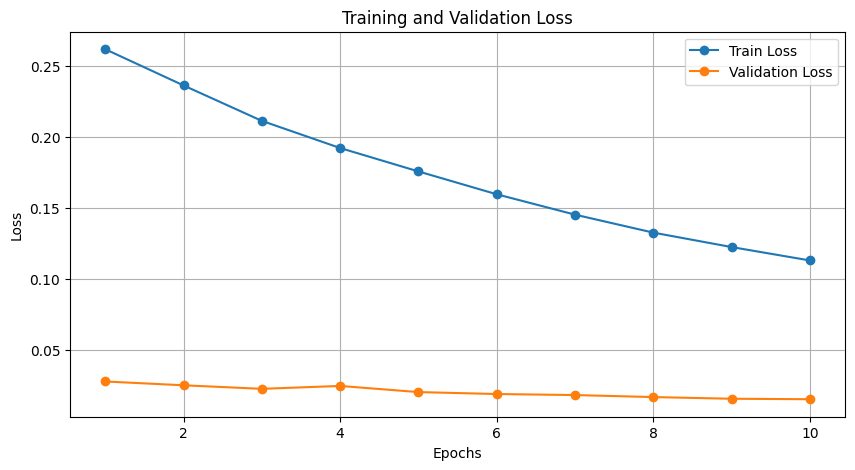

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs+1), train_losses, label="Train Loss", marker='o')
plt.plot(range(1, num_epochs+1), val_losses, label="Validation Loss", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

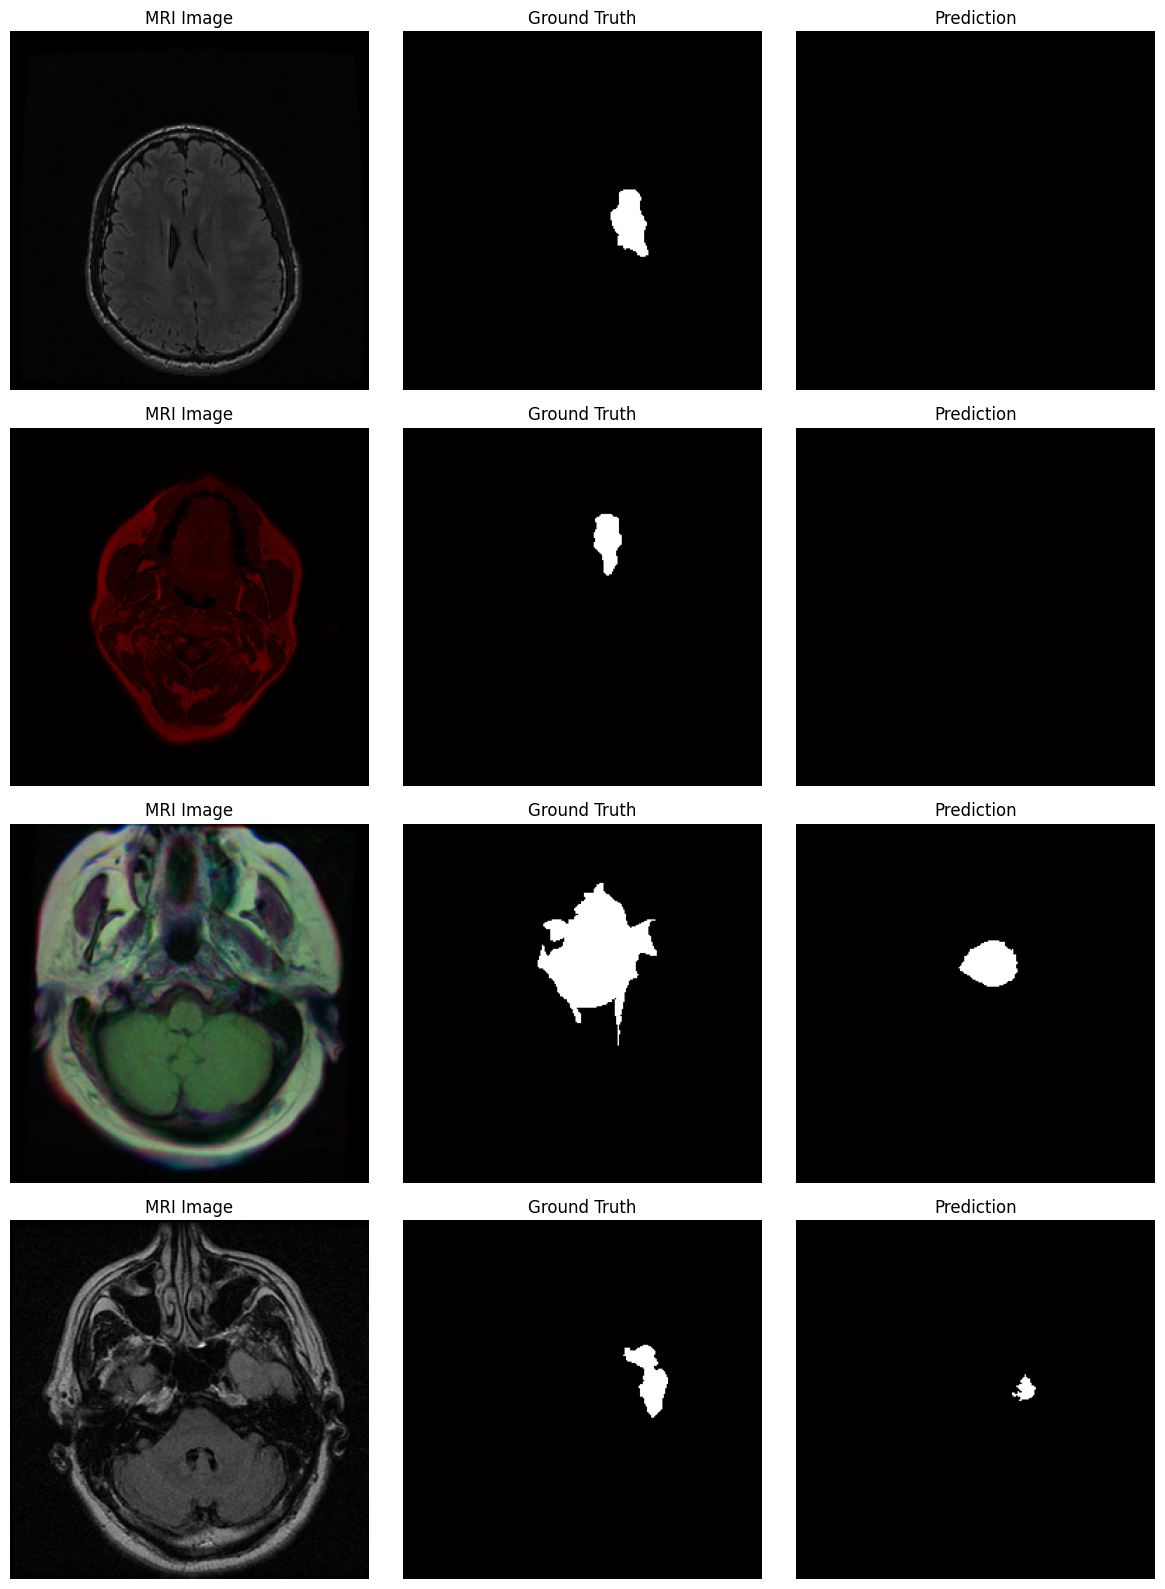

In [22]:
import random
model.eval()
fig, axes = plt.subplots(4, 3, figsize=(12, 16))

indices = random.sample(range(len(test_dataset)), 4)
for i, idx in enumerate(indices):
  image, mask = test_dataset[idx]

  with torch.no_grad():
    input_tensor = image.unsqueeze(0).to(device)
    output = model(input_tensor)
    pred = torch.sigmoid(output)
    pred = (pred > 0.5).float().cpu()

  axes[i, 0].imshow(denormalize(image))
  axes[i, 0].set_title("MRI Image")
  axes[i, 0].axis("off")
  axes[i, 1].imshow(mask.squeeze(), cmap="gray")
  axes[i, 1].set_title("Ground Truth")
  axes[i, 1].axis("off")
  axes[i, 2].imshow(pred.squeeze(), cmap="gray")
  axes[i, 2].set_title("Prediction")
  axes[i, 2].axis("off")
plt.tight_layout()
plt.show()